## **Introduction to Data Science Class**
### **Project 2, Part 2: Introduction to Data Analysis** <br>
### ***"The Impact of College Institutions on Career Salaries through Data Visualizations"*** <br>

**Raven Shaw** <br>
**Student ID: @03099620** <br>
**Friday, April 18, 2025**

#### **Data Wrangling** <br>
*Condensed version of Part I*

In [9]:
import numpy as np
import pandas as pd
df = pd.read_csv("College_Salary.csv")
df_new=df.copy()
df_new.duplicated().sum()
df_drop_dup=df_new.copy()
df_drop_dup.drop_duplicates(inplace=True)
df_drop_dup.fillna({'Mid-Career 10th Percentile Salary': df_new['Mid-Career 10th Percentile Salary'].median(),
               'Mid-Career 90th Percentile Salary': df_new['Mid-Career 90th Percentile Salary'].median()}, inplace=True) 
df_region_type = df_drop_dup.copy()
type_mode = df_region_type['School Type'].mode()[0]
df_region_type['School Type']=df_region_type['School Type'].fillna(type_mode)
df_region_type['Region']=df_region_type['Region'].fillna('Unknown')
df_cleaned = df_region_type.to_csv('college_salary_updated.csv', index=False) 
df_cleaned = pd.read_csv('college_salary_updated.csv')
salary_by_type1 = df_cleaned.groupby('School Type')['Starting Median Salary'].median() 
salary_by_type2 = df_cleaned.groupby('School Type')['Mid-Career Median Salary'].median()
salary_by_region1 = df_cleaned.groupby('Region')['Mid-Career 10th Percentile Salary'].mean()
salary_by_region2 = df_cleaned.groupby('Region')['Mid-Career 90th Percentile Salary'].mean()
salary_inequality = salary_by_region2 - salary_by_region1
def classify_status(salary): #feature engineering beginning with creating a user defined function
    if pd.isnull(salary):
        return 'Unknown'
    elif salary < 30000:
        return 'Lower Class'
    elif salary < 94000:
        return 'Middle Class'
    elif salary < 153000:
        return 'Upper Middle Class'
    else:
        return 'Upper CLass'
df_cleaned=df_cleaned.copy()
df_cleaned['Median Socioeconomic Class']=df_cleaned['Mid-Career Median Salary'].apply(classify_status)
df_cleaned
df_final = pd.read_csv('College_Salary_Cleaned.csv')
df_final

,Unnamed: 0,School Name,Region,School Type,Starting Median Salary,Mid-Career Median Salary,Mid-Career 10th Percentile Salary,Mid-Career 25th Percentile Salary,Mid-Career 75th Percentile Salary,Mid-Career 90th Percentile Salary,Median Socioeconomic Class
0,0,Amherst College,Northeastern,Liberal Arts,54500.0,107000.0,43150.0,84900.0,162000.0,151000.0,Upper Middle Class
1,1,Appalachian State University,Southern,State,40400.0,69100.0,37200.0,50400.0,90800.0,115000.0,Middle Class
2,2,Arizona State University (ASU),Unknown,State,47400.0,84100.0,44600.0,60700.0,114000.0,163000.0,Middle Class
3,3,Arkansas State University (ASU),Southern,State,38700.0,63300.0,33600.0,45300.0,83900.0,118000.0,Middle Class
4,4,Auburn University,Southern,State,45400.0,84700.0,45400.0,62700.0,109000.0,145000.0,Middle Class
...,...,...,...,...,...,...,...,...,...,...,...
247,247,Whitman College,Western,Liberal Arts,43500.0,80100.0,43150.0,64800.0,111000.0,151000.0,Middle Class
248,248,Williams College,Northeastern,Liberal Arts,51700.0,102000.0,43150.0,76400.0,143000.0,151000.0,Upper Middle Class
249,249,Wittenberg University,Midwestern,Liberal Arts,39200.0,78200.0,43150.0,54100.0,131000.0,151000.0,Middle Class
250,250,Worcester Polytechnic Institute (WPI),Northeastern,Engineering,61000.0,114000.0,80000.0,91200.0,137000.0,180000.0,Upper Middle Class


**Data Cleaning Summary**: I began by exploring and cleaning the dataset, addressing missing values with specific imputation methods (mode, median and replace) and removing duplicates to ensure accuracy. After preparing the data, I conducted descriptive analyses—calculating salary statistics by region and school type—and used feature engineering to add a new socioeconomic class variable based on income ranges. A key early insight was the large gap between mid-career salaries at the 10th and 90th percentiles, which pointed to potential income inequality and became a central focus of my visual analysis.

#### **Section 1: INDIVIDUAL, COMPARATIVE AND GROUPED VISUALIZATIONS**

In [11]:
import matplotlib.pyplot as plt #importing libraries
%matplotlib inline
import seaborn as sns

python(91911) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


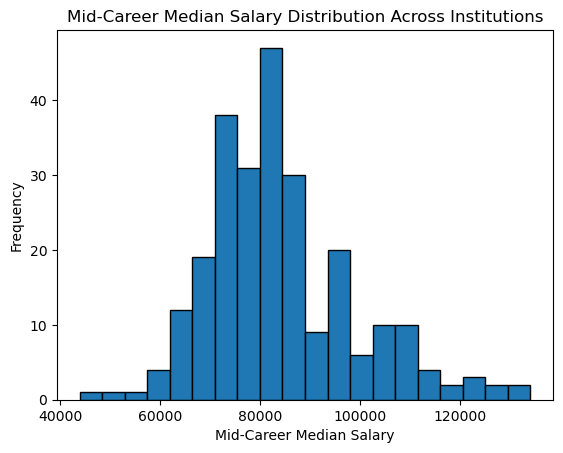

In [12]:
plt.hist(df_cleaned['Mid-Career Median Salary'], bins=20, edgecolor='black') #creating histogram
plt.xlabel("Mid-Career Median Salary") #label for x-axis
plt.ylabel("Frequency") #label for y-axis
plt.title("Mid-Career Median Salary Distribution Across Institutions") #titling of graph
plt.savefig('Raven_Shaw_Project2_Histogram.jpg') #saving graph as a jpg on laptop
plt.show() #display graph

/var/folders/d3/k4jty2hx3bn7vw1kjl5623t40000gn/T/ipykernel_88615/2670002310.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Region', data=df_final, palette='Blues')


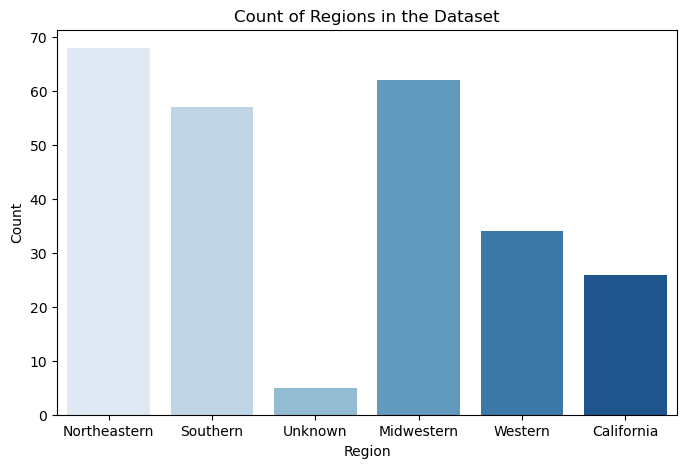

In [67]:
plt.figure(figsize=(8, 5)) #estbalishing size of graph
sns.countplot(x='Region', data=df_final, palette='Blues') #creating count plot graph, including color palette

plt.xlabel("Region") #label for x-axis
plt.ylabel("Count") #Label for y-axis
plt.title("Count of Regions in the Dataset") #titling the graph
plt.savefig('Raven_Shaw_Project2_Count.jpg') #saving graph as a jpg on laptop
plt.show() #display graph

**Explain: What does this visualization reveal about the distribution or spread of values?** <br>
*Answer*: The histogram displays a curve that is slightly skewed to the right, suggesting that a minority of graduates earn exceptionally high salaries, pulling the mean upward. Though the median salary falls around $80,000, there are noticeable outliers on both ends of the salary spectrum, indicating the presence of extreme values—either significantly low or high—within the dataset. Statistically, this means that while most mid-career salaries cluster around the center, a smaller number of institutions report exceptionally low or high salaries. The count of regions helps to display concentration of institutions. As seen, Northeastern has the highest amount of institutions and (excluding Unknown), California has the smallest. This will be important to keep in mind moving forward in understanding future trends as there isn't an equal amount of institutions across the regions. This shows how important context is.  

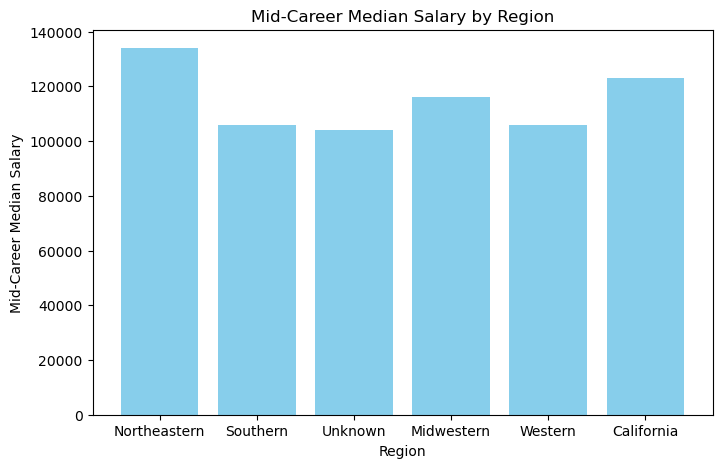

In [81]:
plt.figure(figsize=(8, 5)) #establishing size of graph
region=df_final['Region'] #creating variable for dataframe of 'Region'
mid_salary=df_final['Mid-Career Median Salary'] #creating variable for dataframe of 'Mid-Career Median Salary'
plt.bar(region, mid_salary, color='skyblue') #creating boxplot using variables for easability
a
plt.xlabel("Region") #label for x-axis
plt.ylabel("Mid-Career Median Salary") #label for y-axis
plt.title("Mid-Career Median Salary by Region") #titling the graph
plt.xticks(rotation=0)  # keep rotation straight for preference and length of words
plt.savefig('Raven_Shaw_Project2_BarPlot.jpg') #saving graph as a jpg on laptop

plt.show() #display graph

**Explain: What patterns or differences do you observe among the groups?** <br>
*Answer:* The bar graph reveals that while mid-career median salaries are fairly consistent across most regions—likely due to national wage standards—California and Northeastern stand out with significantly higher earnings. This pattern may be influenced by factors such as higher costs of living, a strong presence of high-paying industries like tech and finance, and the concentration of prestigious institutions in those areas.

#### **Section 2: RELATIONSHIP VISUALIZATIONS**

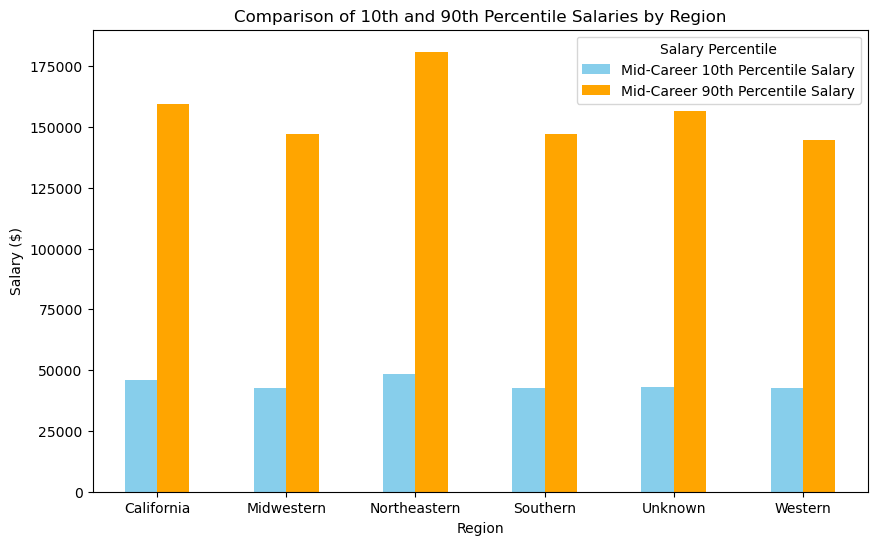

In [79]:

# Group by Region and get the mean 10th and 90th percentile salaries
grouped = df_final.groupby('Region')[[
    'Mid-Career 10th Percentile Salary',
    'Mid-Career 90th Percentile Salary'
]].mean()

# Plot
grouped.plot(kind='bar', figsize=(10, 6), color=['skyblue', 'orange'])

# Labels and title
plt.title('Comparison of 10th and 90th Percentile Salaries by Region')
plt.xlabel('Region')
plt.ylabel('Salary ($)')
plt.legend(title='Salary Percentile')
plt.xticks(rotation=0)

plt.savefig('Raven_Shaw_Project2_Comparison.jpg')


plt.show()


In [43]:
numeric_df = df_final.select_dtypes(include=['float64', 'int64'])


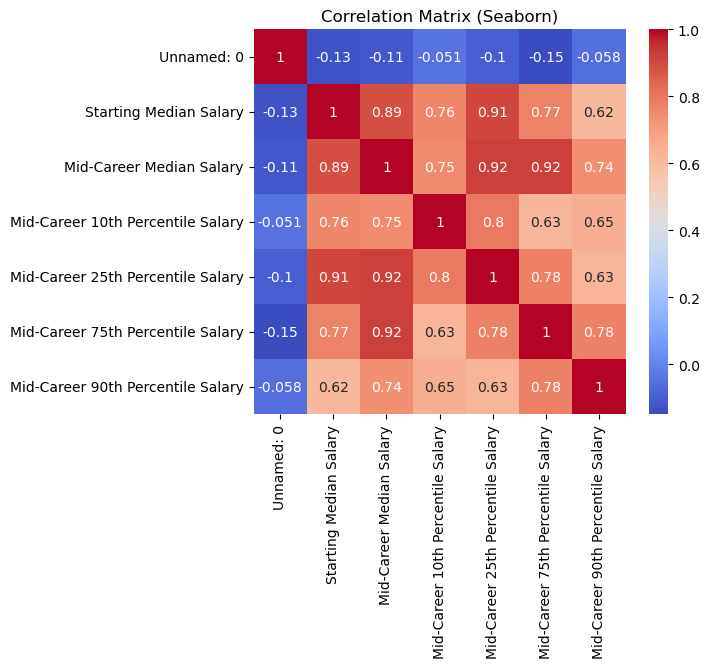

In [75]:
plt.figure(figsize=(6,5))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix (Seaborn)")
plt.savefig('Raven_Shaw_Project2_Heatmap.jpg')

plt.show()

**Explain: Do you observe trends, correlations, or outliers?** <br>
*Answer:* In the first graph depicting the comparison of the 10th and 90th percentiles, the graph reveals which regions have the widest income gaps. The most prominent gap appears in the “Northeastern” group (excludign "Unknown for analysis purposes). Because Northeastern also had the highest median mid-career salary, this finding suggests a potential correlation between high average salaries and high wage inequality within the region. For the heat map, it's evident that higher starting salaries are strongly linked to higher mid-career earnings across all percentiles. Mid-career salary percentiles are also tightly interconnected. Also, the highest earners (90th percentile) show more variability, suggesting additional external factors may influence top-tier outcomes.